In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

df_fact_ticket = pd.read_csv(PROCESSED_DIR / "fact_ticket.csv")

df_fact_ticket["dob"] = pd.to_datetime(df_fact_ticket["dob"], errors="coerce")
df_fact_ticket["time"] = pd.to_datetime(df_fact_ticket["time"], errors="coerce")

In [2]:
from operator import attrgetter
import matplotlib.pyplot as plt
import seaborn as sns

## Overall retention behavior

In [13]:
df_retention_analysis = df_fact_ticket[
    ["customer_id", "time", "status_id", "campaign_type"]
].copy()

In [14]:
df_retention_analysis = df_retention_analysis[
    (df_retention_analysis["time"] < "2020-01-01") &
    (df_retention_analysis["status_id"] == 1)
]

In [15]:
df_retention_analysis["first_month"] = (
    df_retention_analysis
    .groupby("customer_id")["time"]
    .transform("min")
    .dt.to_period("M")
)

df_retention_analysis["current_month"] = (
    df_retention_analysis["time"]
    .dt.to_period("M")
)

df_retention_analysis["subsequent_month"] = (
    df_retention_analysis["current_month"]
    - df_retention_analysis["first_month"]
).apply(attrgetter("n"))

In [16]:
df_retention_analysis.head(15)

,customer_id,time,status_id,campaign_type,first_month,current_month,subsequent_month
11326,100009,2019-11-09 16:19:41.008,1,direct discount,2019-04,2019-11,7
11327,101892,2019-11-16 16:35:02.953,1,direct discount,2019-08,2019-11,3
11328,105574,2019-11-09 18:10:13.461,1,direct discount,2019-11,2019-11,0
11331,111681,2019-11-16 22:02:42.851,1,direct discount,2019-11,2019-11,0
11332,116896,2019-11-13 17:32:32.892,1,no_campaign,2019-11,2019-11,0
11334,122042,2019-11-17 05:01:48.136,1,direct discount,2019-10,2019-11,1
11335,124200,2019-11-09 10:42:42.694,1,direct discount,2019-11,2019-11,0
11336,131444,2019-11-10 11:12:31.461,1,no_campaign,2019-11,2019-11,0
11337,131562,2019-11-10 17:25:02.482,1,direct discount,2019-11,2019-11,0
11338,134348,2019-11-09 02:10:30.490,1,no_campaign,2019-11,2019-11,0


In [17]:
df_cohort = (
    df_retention_analysis
    .groupby(
        ["first_month", "current_month", "subsequent_month"]
    )
    .agg(
        n_customers=("customer_id", "nunique")
    )
    .reset_index()
)

In [18]:
df_cohort.head(5)

,first_month,current_month,subsequent_month,n_customers
0,2019-01,2019-01,0,1348
1,2019-01,2019-02,1,50
2,2019-01,2019-03,2,35
3,2019-01,2019-04,3,26
4,2019-01,2019-05,4,25


In [19]:
df_cohort_pivot = (
    df_cohort
    .pivot_table(
        index="first_month",
        columns="subsequent_month",
        values="n_customers"
    )
)

In [20]:
df_cohort_pivot

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2019-01,1348.0,50.0,35.0,26.0,25.0,33.0,36.0,29.0,18.0,35.0,21.0,20.0
2019-02,1293.0,58.0,88.0,64.0,78.0,50.0,58.0,30.0,46.0,29.0,35.0,NaN
2019-03,745.0,51.0,48.0,49.0,33.0,33.0,30.0,34.0,23.0,14.0,NaN,NaN
2019-04,2922.0,101.0,103.0,87.0,92.0,66.0,96.0,63.0,42.0,NaN,NaN,NaN
2019-05,3226.0,145.0,118.0,129.0,90.0,93.0,90.0,62.0,NaN,NaN,NaN,NaN
2019-06,3062.0,131.0,151.0,98.0,133.0,114.0,63.0,NaN,NaN,NaN,NaN,NaN
2019-07,2611.0,121.0,79.0,99.0,78.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,3735.0,112.0,155.0,106.0,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,2169.0,117.0,67.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
cohort_size = df_cohort_pivot.iloc[:, 0]

retention_matrix = (
    df_cohort_pivot
    .divide(cohort_size, axis=0)
)

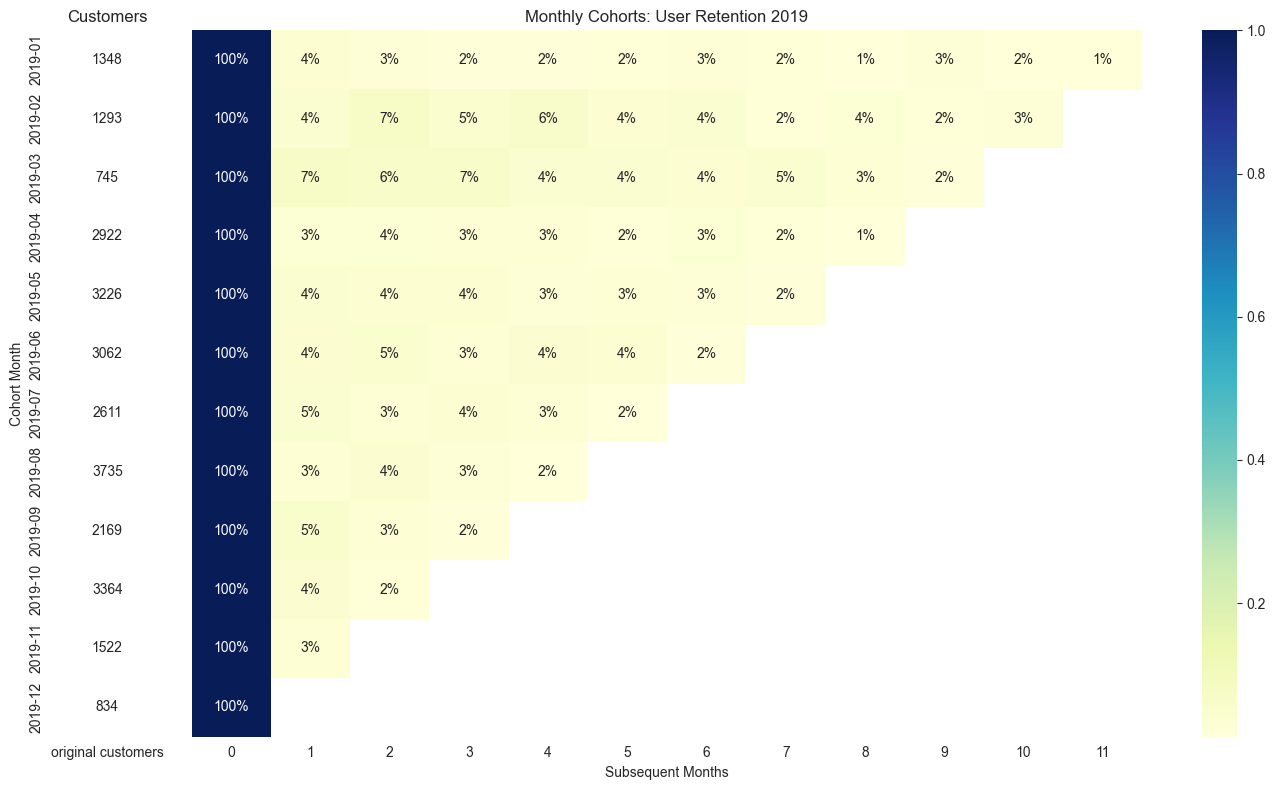

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

# 1. cohort size = cột month_0
cohort_size = df_cohort_pivot.iloc[:, 0]

# 2. retention matrix %
retention_matrix = df_cohort_pivot.divide(cohort_size, axis=0)

# 3. tạo dataframe cohort size để vẽ bên trái
cohort_size_df = pd.DataFrame(cohort_size)
cohort_size_df.columns = ["original customers"]

# 4. vẽ
with sns.axes_style("white"):
    fig, ax = plt.subplots(
        1, 2,
        figsize=(14, 8),
        sharey=True,
        gridspec_kw={"width_ratios": [1, 11]}
    )

    # Bảng original customers bên trái
    white_cmap = mcolors.ListedColormap(["white"])

    sns.heatmap(
        cohort_size_df,
        annot=True,
        cbar=False,
        fmt="g",
        cmap=white_cmap,
        ax=ax[0]
    )

    ax[0].set_title("Customers")
    ax[0].set_xlabel("")
    ax[0].set_ylabel("Cohort Month")

    # Heatmap retention bên phải
    sns.heatmap(
        retention_matrix,
        mask=retention_matrix.isnull(),
        annot=True,
        fmt=".0%",
        cmap="YlGnBu",
        ax=ax[1]
    )

    ax[1].set_title("Monthly Cohorts: User Retention 2019")
    ax[1].set_xlabel("Subsequent Months")
    ax[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

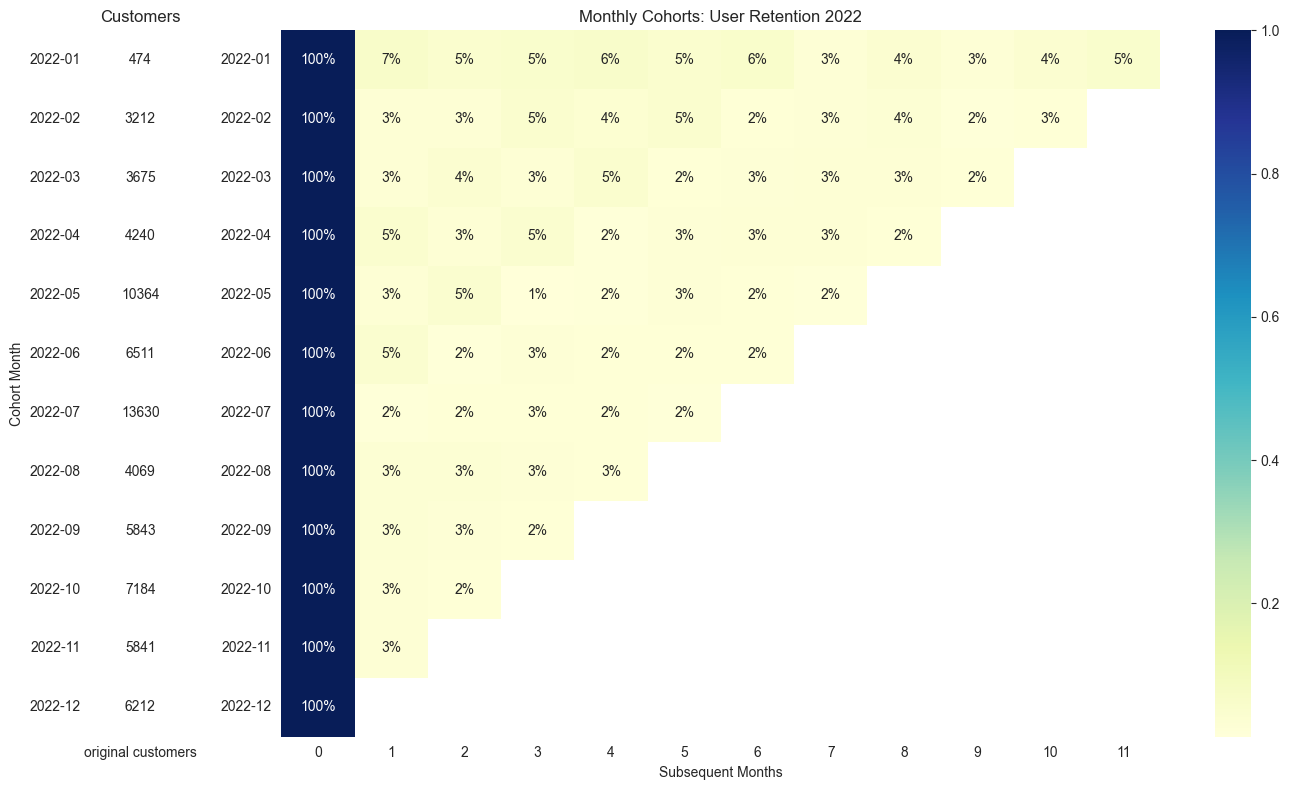

In [28]:
# ===== STEP 1: FILTER DATA 2022 + SUCCESSFUL ORDERS =====

df_selected_time = df_fact_ticket[
    (pd.to_datetime(df_fact_ticket["time"]) >= "2022-01-01") &
    (pd.to_datetime(df_fact_ticket["time"]) < "2023-01-01") &
    (df_fact_ticket["status_id"] == 1)
].copy()

df_selected_time["time"] = pd.to_datetime(df_selected_time["time"])

# ===== STEP 2: CREATE COHORT COLUMNS =====

df_selected_time["first_month"] = (
    df_selected_time
    .groupby("customer_id")["time"]
    .transform("min")
    .dt.to_period("M")
)

df_selected_time["current_month"] = (
    df_selected_time["time"]
    .dt.to_period("M")
)

df_selected_time["subsequent_month"] = (
    df_selected_time["current_month"] - df_selected_time["first_month"]
).apply(attrgetter("n"))

# ===== STEP 3: GROUP BY COHORT =====

df_cohort = (
    df_selected_time
    .groupby(["first_month", "current_month", "subsequent_month"])
    .agg(n_customers=("customer_id", "nunique"))
    .reset_index()
)

# ===== STEP 4: PIVOT TABLE =====

df_cohort_pivot = (
    df_cohort
    .pivot_table(
        index="first_month",
        columns="subsequent_month",
        values="n_customers"
    )
)

# ===== STEP 5: RETENTION MATRIX =====

cohort_size = df_cohort_pivot.iloc[:, 0]

retention_matrix = (
    df_cohort_pivot
    .divide(cohort_size, axis=0)
)

# ===== STEP 6: COHORT SIZE TABLE =====

cohort_size_df = pd.DataFrame(cohort_size)
cohort_size_df.columns = ["original customers"]

# ===== STEP 7: PLOT COHORT HEATMAP =====

with sns.axes_style("white"):

    fig, ax = plt.subplots(
        1, 2,
        figsize=(14, 8),
        gridspec_kw={"width_ratios": [1, 11]}
    )

    white_cmap = mcolors.ListedColormap(["white"])

    # LEFT: original customers
    sns.heatmap(
        cohort_size_df,
        annot=True,
        cbar=False,
        fmt="g",
        cmap=white_cmap,
        ax=ax[0]
    )

    ax[0].set_title("Customers")
    ax[0].set_xlabel("")
    ax[0].set_ylabel("Cohort Month")
    ax[0].set_yticklabels(cohort_size_df.index.astype(str), rotation=0)

    # RIGHT: retention heatmap
    sns.heatmap(
        retention_matrix,
        mask=retention_matrix.isnull(),
        annot=True,
        fmt=".0%",
        cmap="YlGnBu",
        ax=ax[1]
    )

    ax[1].set_title("Monthly Cohorts: User Retention 2022")
    ax[1].set_xlabel("Subsequent Months")
    ax[1].set_ylabel("")
    ax[1].set_yticklabels(retention_matrix.index.astype(str), rotation=0)

    plt.tight_layout()
    plt.show()

🎯 6. Final Conclusion
🔥 Key Finding

The platform demonstrates strong acquisition capability but weak retention capability across both years.

While 2022 achieved significantly larger customer volumes, retention rates remained consistently low and comparable to 2019.

This suggests that customer growth was primarily driven by external demand factors such as promotions and movie releases rather than sustainable customer loyalty.

🎯 Business Recommendations
🚀 Improve post-purchase engagement
personalized recommendations
loyalty programs
membership tiers
🚀 Convert transactional users into recurring users
targeted remarketing
retention campaigns after booking
cross-selling upcoming movies
🚀 Reduce dependence on blockbuster releases
improve platform stickiness
encourage habitual app usage
develop ecosystem-based engagement

## Compare: Retention of Promotion Customers & Organic Customers


In [3]:
df_fact_ticket.head(5)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,no_error,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,no_error,browser,website
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,no_campaign,Order successful,no_error,unknown,mobile
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,no_error,devicemodel,mobile
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,no_error,devicemodel,mobile


In [5]:
# 1. Lọc dữ liệu theo status và thời gian, chỉ giữ các cột cần thiết, rồi sắp xếp
df_data_check = (
    df_fact_ticket[(df_fact_ticket['status_id']==1) & (df_fact_ticket['time'] > '2022-01-01')]
    [['customer_id', 'ticket_id', 'time', 'campaign_type']]
    .sort_values(by=['customer_id', 'time'])
)

# 2. Đánh số thứ tự giao dịch cho từng customer_id
df_data_check['row_number'] = df_data_check.groupby('customer_id').cumcount() + 1

# 3. Kiểm tra kết quả
df_data_check.head(10)

,customer_id,ticket_id,time,campaign_type,row_number
66483,100003,34c4764b4afa000af4c33a525f20eace,2022-05-22 12:52:12.105,no_campaign,1
10000,100004,1c4aa39842bfc83dbb5856c25a33d9cb,2022-12-20 06:26:21.373,no_campaign,1
108792,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,direct discount,1
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,direct discount,1
5585,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,direct discount,2
69403,100013,f95441286dcfa045f61a5760662616e1,2022-05-05 12:22:44.587,no_campaign,1
140481,100018,1e40fb2d0f6264ed3127f79b1a12c9c9,2022-09-07 21:13:17.896,no_campaign,1
90593,100018,9a959ff1649950949ff2c0aff4b62205,2022-11-19 16:25:43.981,direct discount,2
35269,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,direct discount,1
16648,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,direct discount,1


In [6]:
df_data_check["type"] = df_data_check["campaign_type"].apply(
    lambda x: "non-promotion" if x == "no_campaign" else "promotion"
)

In [7]:
df_data_check.head(10)

,customer_id,ticket_id,time,campaign_type,row_number,type
66483,100003,34c4764b4afa000af4c33a525f20eace,2022-05-22 12:52:12.105,no_campaign,1,non-promotion
10000,100004,1c4aa39842bfc83dbb5856c25a33d9cb,2022-12-20 06:26:21.373,no_campaign,1,non-promotion
108792,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,direct discount,1,promotion
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,direct discount,1,promotion
5585,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,direct discount,2,promotion
69403,100013,f95441286dcfa045f61a5760662616e1,2022-05-05 12:22:44.587,no_campaign,1,non-promotion
140481,100018,1e40fb2d0f6264ed3127f79b1a12c9c9,2022-09-07 21:13:17.896,no_campaign,1,non-promotion
90593,100018,9a959ff1649950949ff2c0aff4b62205,2022-11-19 16:25:43.981,direct discount,2,promotion
35269,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,direct discount,1,promotion
16648,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,direct discount,1,promotion


In [8]:
df_data_check[(df_data_check["type"] == "promotion" ) & (df_data_check["row_number"] == 1)]['customer_id'].nunique()

46188

In [9]:
total_promotion_customers = df_data_check[df_data_check["type"] == "promotion"]['customer_id'].nunique()
print(total_promotion_customers)

47506


In [10]:
46188/47506

0.9722561360670231

In [12]:
# ===== Nhóm promotion =====
# Khách hàng có đơn đầu tiên là promotion
first_promo_customers = df_data_check[
    (df_data_check['type'] == 'promotion') & 
    (df_data_check['row_number'] == 1)
]['customer_id'].unique()

# Lọc giao dịch lần 2 của nhóm promotion
second_purchase_promo = df_data_check[
    (df_data_check['customer_id'].isin(first_promo_customers)) &
    (df_data_check['row_number'] == 2)
]

# Tỷ lệ retention lần 2 nhóm promotion
promo_returned = second_purchase_promo['customer_id'].nunique()
promo_retention_rate = promo_returned / len(first_promo_customers) * 100


# ===== Nhóm non-promotion (organic) =====
# Khách hàng có đơn đầu tiên là non-promotion
first_nonpromo_customers = df_data_check[
    (df_data_check['type'] == 'non-promotion') & 
    (df_data_check['row_number'] == 1)
]['customer_id'].unique()

# Lọc giao dịch lần 2 của nhóm non-promotion
second_purchase_nonpromo = df_data_check[
    (df_data_check['customer_id'].isin(first_nonpromo_customers)) &
    (df_data_check['row_number'] == 2)
]

# Tỷ lệ retention lần 2 nhóm non-promotion
nonpromo_returned = second_purchase_nonpromo['customer_id'].nunique()
nonpromo_retention_rate = nonpromo_returned / len(first_nonpromo_customers) * 100


# ===== In kết quả so sánh =====
print(f"Promotion: {len(first_promo_customers)} khách lần đầu, {promo_returned} quay lại, tỷ lệ {promo_retention_rate:.2f}%")
print(f"Non-promotion: {len(first_nonpromo_customers)} khách lần đầu, {nonpromo_returned} quay lại, tỷ lệ {nonpromo_retention_rate:.2f}%")

Promotion: 46188 khách lần đầu, 6045 quay lại, tỷ lệ 13.09%
Non-promotion: 25067 khách lần đầu, 3057 quay lại, tỷ lệ 12.20%
